# Trees vs Random Forest vs XGBoost - Flight Centre Booking Conversion

**Goal:** reproduce the DataTalksClub ML Zoomcamp *trees* module (decision tree -> random
forest -> XGBoost) on a **mock Flight Centre Australia booking-conversion dataset**.

**Business problem:** given a sales lead / quote, predict the probability the customer
actually **books the trip** (`converted = 1`) vs. walks away (`converted = 0`). This is a
propensity / lead-scoring problem - travel consultants can only chase a limited number of
leads, so ranking them well (high ROC-AUC) directly drives revenue.

We walk through, exactly like the Zoomcamp notebook:
1. Generate a realistic synthetic dataset (signal + interactions + noise).
2. Train/validation/test split + one-hot encoding.
3. **Decision tree** - and watch it overfit.
4. **Parameter tuning** - `max_depth`, `min_samples_leaf`.
5. **Random forest** - `n_estimators`, `max_depth`, feature importance.
6. **XGBoost** - sequential boosting with a watchlist + tuning.
7. **Model comparison** on validation, final evaluation on the held-out test set, save model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

import xgboost as xgb

sns.set_style("whitegrid")
%matplotlib inline

RANDOM_STATE = 11
print("xgboost", xgb.__version__)

xgboost 3.2.0


## 1. Generate the mock Flight Centre dataset

There is no real customer data here - we *simulate* it. We build a latent "booking
intention" score from realistic drivers (engagement, value, urgency, segment, prior
cancellations) **plus a couple of interactions** (the kind of non-linear signal trees love),
then add noise and convert to a 0/1 outcome via a logistic link. The noise keeps AUC
realistic (~0.80-0.88) instead of a trivially perfect 1.0.

In [2]:
def generate_flight_centre_data(n=8000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)

    lead_source = rng.choice(
        ['website', 'phone', 'walk_in', 'social', 'partner'],
        size=n, p=[0.40, 0.20, 0.10, 0.20, 0.10])
    destination_type = rng.choice(
        ['domestic', 'international', 'cruise'],
        size=n, p=[0.45, 0.45, 0.10])
    customer_segment = rng.choice(
        ['new', 'returning', 'vip'],
        size=n, p=[0.55, 0.35, 0.10])
    device = rng.choice(['mobile', 'desktop', 'tablet'], size=n, p=[0.55, 0.35, 0.10])
    season = rng.choice(['peak', 'shoulder', 'off'], size=n, p=[0.35, 0.40, 0.25])

    age = rng.integers(18, 75, size=n)
    past_bookings = rng.poisson(1.2, size=n)
    days_to_travel = rng.integers(3, 365, size=n)
    num_travellers = rng.integers(1, 6, size=n)
    quote_value = np.round(rng.gamma(shape=2.0, scale=1500, size=n) + 300, 2)  # AUD
    email_engagement = np.clip(rng.beta(2, 3, size=n), 0, 1)
    prior_cancellations = rng.binomial(3, 0.12, size=n)
    contacted_count = rng.poisson(2.0, size=n) + 1

    # --- latent booking intention (the "truth" the models must recover) ---
    z = -2.2
    z += 4.5 * email_engagement
    z += 0.8 * past_bookings
    z += np.where(customer_segment == 'vip', 1.8, 0.0)
    z += np.where(customer_segment == 'returning', 0.8, 0.0)
    z += np.where(lead_source == 'partner', 1.1, 0.0)
    z += np.where(lead_source == 'walk_in', 0.7, 0.0)
    z -= np.where(lead_source == 'social', 0.6, 0.0)
    z -= 1.1 * prior_cancellations
    z += 0.15 * (contacted_count - 2)
    z -= 0.004 * np.maximum(days_to_travel - 30, 0)    # urgency: closer trips convert more
    z -= 0.00009 * quote_value                          # very expensive quotes convert less

    # interactions (non-linear signal -> favours trees/boosting over linear models)
    z += np.where((destination_type == 'international') & (email_engagement > 0.6), 1.6, 0.0)
    z += np.where((season == 'peak') & (num_travellers >= 3), 1.2, 0.0)
    z += np.where((device == 'mobile') & (days_to_travel < 14), 0.9, 0.0)

    z += rng.normal(0, 0.4, size=n)  # irreducible noise

    prob = 1 / (1 + np.exp(-z))
    converted = rng.binomial(1, prob)

    df = pd.DataFrame({
        'lead_source': lead_source,
        'destination_type': destination_type,
        'customer_segment': customer_segment,
        'device': device,
        'season': season,
        'age': age,
        'past_bookings': past_bookings,
        'days_to_travel': days_to_travel,
        'num_travellers': num_travellers,
        'quote_value': quote_value,
        'email_engagement': np.round(email_engagement, 3),
        'prior_cancellations': prior_cancellations,
        'contacted_count': contacted_count,
        'converted': converted,
    })
    return df

df = generate_flight_centre_data()
df.to_csv('flight-centre-bookings.csv', index=False)
print(df.shape)
df.head()

(8000, 14)


,lead_source,destination_type,customer_segment,device,season,age,past_bookings,days_to_travel,num_travellers,quote_value,email_engagement,prior_cancellations,contacted_count,converted
0,website,international,new,desktop,peak,22,3,195,3,6102.75,0.301,0,4,1
1,phone,international,new,desktop,shoulder,39,1,43,1,2884.12,0.490,0,2,1
2,walk_in,cruise,new,desktop,peak,31,1,317,4,3199.12,0.290,1,1,1
3,website,international,new,mobile,peak,56,0,121,4,12210.14,0.286,0,1,0
4,website,domestic,new,desktop,peak,32,3,113,3,3414.36,0.699,0,5,1


In [3]:
print("Overall conversion rate:", round(df.converted.mean(), 3))
df.describe().round(2)

Overall conversion rate: 0.548


,age,past_bookings,days_to_travel,num_travellers,quote_value,email_engagement,prior_cancellations,contacted_count,converted
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,46.01,1.21,183.37,3.01,3251.56,0.40,0.36,3.02,0.55
std,16.42,1.10,104.49,1.42,2103.92,0.20,0.57,1.44,0.50
min,18.00,0.00,3.00,1.00,321.30,0.00,0.00,1.00,0.00
25%,32.00,0.00,92.00,2.00,1721.20,0.24,0.00,2.00,0.00
50%,46.00,1.00,183.00,3.00,2749.88,0.38,0.00,3.00,1.00
75%,61.00,2.00,273.00,4.00,4284.69,0.54,1.00,4.00,1.00
max,74.00,7.00,364.00,5.00,17638.29,0.99,3.00,10.00,1.00


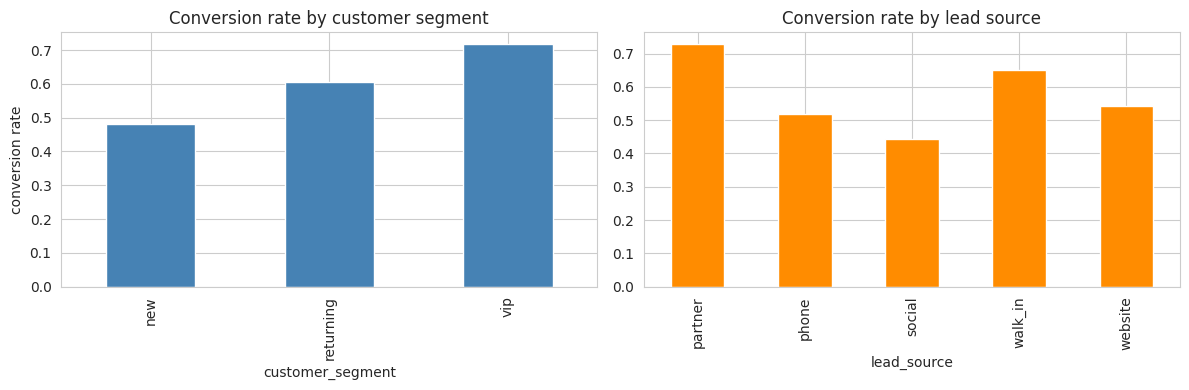

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('customer_segment').converted.mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Conversion rate by customer segment')
axes[0].set_ylabel('conversion rate')
df.groupby('lead_source').converted.mean().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Conversion rate by lead source')
plt.tight_layout()
plt.show()

## 2. Train / validation / test split + encoding

Same discipline as the Zoomcamp notebook: **60% train / 20% validation / 20% test**. The
test set is touched exactly **once**, at the very end. Categorical features are one-hot
encoded with `DictVectorizer`.

In [5]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=RANDOM_STATE)

for d in (df_train, df_val, df_test, df_full_train):
    d.reset_index(drop=True, inplace=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values
y_full_train = df_full_train.converted.values

def to_X(dframe, dv, fit=False):
    dicts = dframe.drop(columns='converted').to_dict(orient='records')
    return dv.fit_transform(dicts) if fit else dv.transform(dicts)

dv = DictVectorizer(sparse=False)
X_train = to_X(df_train, dv, fit=True)
X_val = to_X(df_val, dv)
X_test = to_X(df_test, dv)

features = list(dv.get_feature_names_out())
print(f"train={X_train.shape}, val={X_val.shape}, test={X_test.shape}, n_features={len(features)}")

train=(4800, 25), val=(1600, 25), test=(1600, 25), n_features=25


## 3. Decision tree - and watching it overfit

First an **unrestricted** tree. Like the credit-risk notebook, it scores ~1.0 on training
but much lower on validation - the classic overfitting signature (the gap between train and
val AUC).

In [6]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

auc_train = roc_auc_score(y_train, dt.predict_proba(X_train)[:, 1])
auc_val = roc_auc_score(y_val, dt.predict_proba(X_val)[:, 1])
print(f"Unrestricted tree -> train AUC: {auc_train:.3f} | val AUC: {auc_val:.3f}  (overfit gap!)")

Unrestricted tree -> train AUC: 1.000 | val AUC: 0.639  (overfit gap!)


In [7]:
# A shallow tree generalises better and is human-readable
dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
print(f"depth=3 -> train AUC: {roc_auc_score(y_train, dt.predict_proba(X_train)[:,1]):.3f} | "
      f"val AUC: {roc_auc_score(y_val, dt.predict_proba(X_val)[:,1]):.3f}\n")
print(export_text(dt, feature_names=features))

depth=3 -> train AUC: 0.741 | val AUC: 0.737

|--- email_engagement <= 0.47
|   |--- past_bookings <= 1.50
|   |   |--- days_to_travel <= 231.50
|   |   |   |--- class: 0
|   |   |--- days_to_travel >  231.50
|   |   |   |--- class: 0
|   |--- past_bookings >  1.50
|   |   |--- prior_cancellations <= 0.50
|   |   |   |--- class: 1
|   |   |--- prior_cancellations >  0.50
|   |   |   |--- class: 0
|--- email_engagement >  0.47
|   |--- email_engagement <= 0.59
|   |   |--- prior_cancellations <= 0.50
|   |   |   |--- class: 1
|   |   |--- prior_cancellations >  0.50
|   |   |   |--- class: 0
|   |--- email_engagement >  0.59
|   |   |--- destination_type=international <= 0.50
|   |   |   |--- class: 1
|   |   |--- destination_type=international >  0.50
|   |   |   |--- class: 1



## 4. Decision tree parameter tuning

Grid-search `max_depth` and `min_samples_leaf` on the **validation** set.

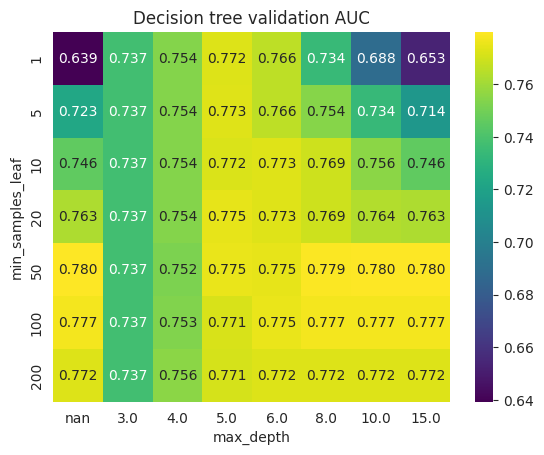

Best tree: {'max_depth': 15.0, 'min_samples_leaf': 50.0, 'auc': 0.7798450709763673}


In [8]:
scores = []
for depth in [3, 4, 5, 6, 8, 10, 15, None]:
    for leaf in [1, 5, 10, 20, 50, 100, 200]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf,
                                    random_state=RANDOM_STATE)
        dt.fit(X_train, y_train)
        auc = roc_auc_score(y_val, dt.predict_proba(X_val)[:, 1])
        scores.append((depth, leaf, auc))

df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
pivot = df_scores.pivot(index='min_samples_leaf', columns='max_depth', values='auc')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('Decision tree validation AUC')
plt.show()

best = df_scores.sort_values('auc', ascending=False).iloc[0]
print("Best tree:", best.to_dict())

In [9]:
dt_depth = int(best.max_depth) if pd.notna(best.max_depth) else None
dt = DecisionTreeClassifier(max_depth=dt_depth,
                            min_samples_leaf=int(best.min_samples_leaf),
                            random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
auc_dt = roc_auc_score(y_val, dt.predict_proba(X_val)[:, 1])
print(f"Tuned decision tree val AUC: {auc_dt:.3f}")

Tuned decision tree val AUC: 0.780


## 5. Random forest

A forest of decorrelated trees (bagging + random feature subsets). It reduces the single
tree's **variance** and lifts AUC, with very little tuning.

### 5a. Number of estimators
More trees help up to a plateau and **never overfit** - they just cost more compute.

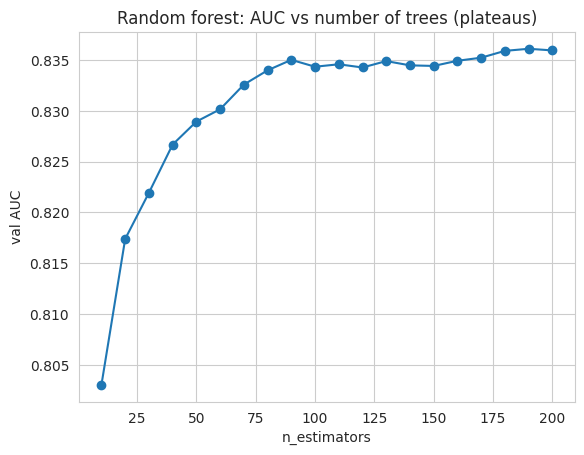

In [10]:
scores = []
for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
    scores.append((n, auc))

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
plt.plot(df_scores.n_estimators, df_scores.auc, marker='o')
plt.xlabel('n_estimators'); plt.ylabel('val AUC')
plt.title('Random forest: AUC vs number of trees (plateaus)')
plt.show()

### 5b. Max depth (with the forest)

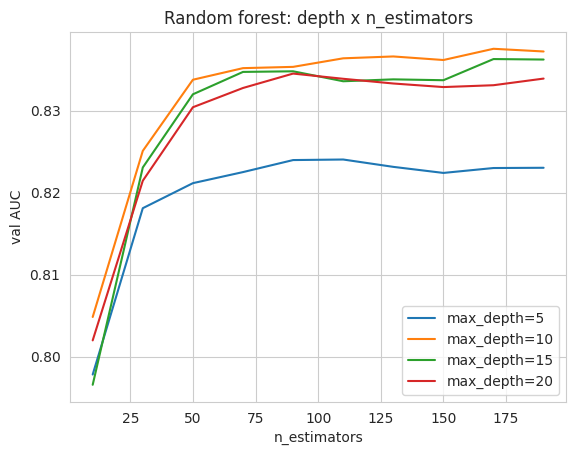

Best RF config: {'max_depth': 10.0, 'n_estimators': 170.0, 'auc': 0.8375290000393222}


In [11]:
scores = []
for d in [5, 10, 15, 20]:
    for n in range(10, 201, 20):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d,
                                    random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(X_train, y_train)
        auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
        scores.append((d, n, auc))

df_scores = pd.DataFrame(scores, columns=['max_depth', 'n_estimators', 'auc'])
for d in [5, 10, 15, 20]:
    sub = df_scores[df_scores.max_depth == d]
    plt.plot(sub.n_estimators, sub.auc, label=f'max_depth={d}')
plt.legend(); plt.xlabel('n_estimators'); plt.ylabel('val AUC')
plt.title('Random forest: depth x n_estimators')
plt.show()

best_rf = df_scores.sort_values('auc', ascending=False).iloc[0]
print("Best RF config:", best_rf.to_dict())

In [12]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=int(best_rf.max_depth),
                            min_samples_leaf=3,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
auc_rf = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
print(f"Tuned random forest val AUC: {auc_rf:.3f}")

Tuned random forest val AUC: 0.835


### 5c. Feature importance
Which drivers does the forest rely on? This is the bridge from model to **business insight**
(and a leakage check). For customer-facing decisions, back this up with SHAP.

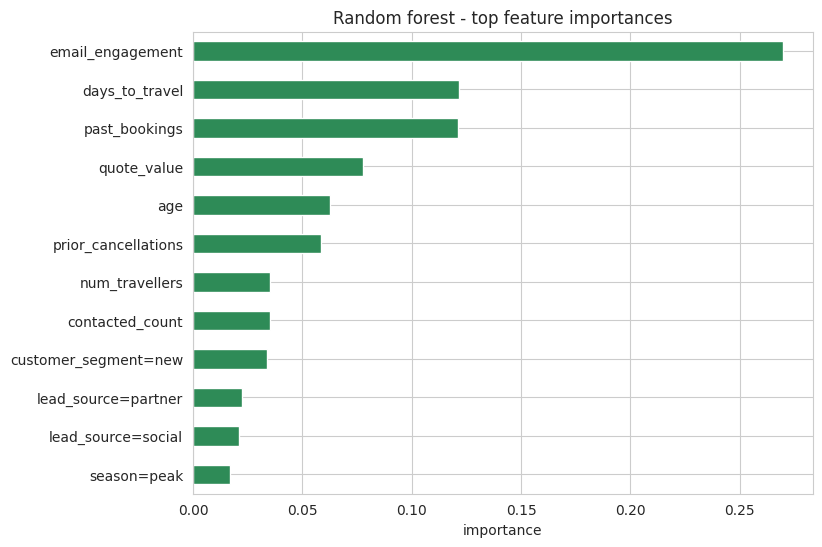

email_engagement        0.269970
days_to_travel          0.121584
past_bookings           0.121351
quote_value             0.077935
age                     0.062707
prior_cancellations     0.058350
num_travellers          0.035337
contacted_count         0.035109
customer_segment=new    0.034013
lead_source=partner     0.022582
lead_source=social      0.020855
season=peak             0.016758
dtype: float64

In [13]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances.head(12).iloc[::-1].plot(kind='barh', figsize=(8, 6), color='seagreen')
plt.title('Random forest - top feature importances')
plt.xlabel('importance')
plt.show()
importances.head(12)

## 6. XGBoost (gradient boosting)

Instead of averaging independent trees, boosting builds trees **sequentially**, each one
correcting the previous ensemble's errors. The **watchlist** lets us watch train vs. val AUC
per round and spot overfitting live.

In [14]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    'seed': RANDOM_STATE,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round=50,
                  evals=watchlist, verbose_eval=10)
auc_xgb_base = roc_auc_score(y_val, model.predict(dval))
print(f"\nBaseline XGBoost val AUC: {auc_xgb_base:.3f}")

[0]	train-auc:0.81937	val-auc:0.76571


[10]	train-auc:0.90964	val-auc:0.82589


[20]	train-auc:0.93918	val-auc:0.82884


[30]	train-auc:0.95409	val-auc:0.82742


[40]	train-auc:0.97012	val-auc:0.82755


[49]	train-auc:0.98161	val-auc:0.82485



Baseline XGBoost val AUC: 0.825


### 6a. Tuning `eta`, `max_depth` and rounds with early stopping

In [15]:
best_xgb = {'auc': 0}
for eta in [0.3, 0.1, 0.05]:
    for max_depth in [3, 4, 6]:
        params = {**xgb_params, 'eta': eta, 'max_depth': max_depth}
        m = xgb.train(params, dtrain, num_boost_round=500,
                      evals=watchlist, early_stopping_rounds=20, verbose_eval=False)
        auc = roc_auc_score(y_val, m.predict(dval))
        if auc > best_xgb['auc']:
            best_xgb = {'auc': auc, 'eta': eta, 'max_depth': max_depth,
                        'best_iteration': m.best_iteration, 'model': m}
        print(f"eta={eta}, max_depth={max_depth} -> val AUC {auc:.3f} "
              f"(best_iter={m.best_iteration})")

print("\nBest XGBoost:", {k: v for k, v in best_xgb.items() if k != 'model'})
auc_xgb = best_xgb['auc']

eta=0.3, max_depth=3 -> val AUC 0.842 (best_iter=52)
eta=0.3, max_depth=4 -> val AUC 0.837 (best_iter=21)
eta=0.3, max_depth=6 -> val AUC 0.827 (best_iter=16)


eta=0.1, max_depth=3 -> val AUC 0.846 (best_iter=139)


eta=0.1, max_depth=4 -> val AUC 0.843 (best_iter=111)
eta=0.1, max_depth=6 -> val AUC 0.836 (best_iter=73)


eta=0.05, max_depth=3 -> val AUC 0.847 (best_iter=254)


eta=0.05, max_depth=4 -> val AUC 0.843 (best_iter=204)


eta=0.05, max_depth=6 -> val AUC 0.837 (best_iter=155)

Best XGBoost: {'auc': 0.8473563760764422, 'eta': 0.05, 'max_depth': 3, 'best_iteration': 254}


## 7. Model comparison & final evaluation

Compare all three tuned models on the **validation** set, pick the winner, retrain it on
**train + validation**, and report the honest number on the **held-out test set**.

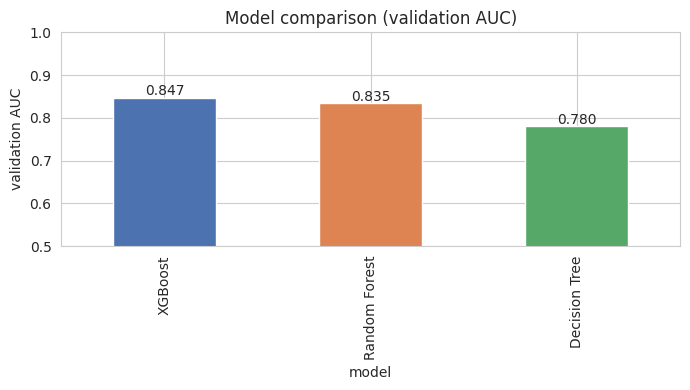

,model,val_auc
0,XGBoost,0.847356
1,Random Forest,0.834507
2,Decision Tree,0.779845


In [16]:
results = pd.DataFrame({
    'model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'val_auc': [auc_dt, auc_rf, auc_xgb],
}).sort_values('val_auc', ascending=False).reset_index(drop=True)

ax = results.plot(kind='bar', x='model', y='val_auc', legend=False,
                  color=['#4c72b0', '#dd8452', '#55a868'], figsize=(7, 4))
ax.set_ylim(0.5, 1.0); ax.set_ylabel('validation AUC')
ax.set_title('Model comparison (validation AUC)')
for i, v in enumerate(results.val_auc):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()
results

In [17]:
# Retrain the winner (XGBoost) on train+validation, evaluate once on test
X_full_train = to_X(df_full_train, dv, fit=True)
X_test = to_X(df_test, dv)
features = list(dv.get_feature_names_out())

dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=features)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=features)

final_params = {**xgb_params, 'eta': best_xgb['eta'], 'max_depth': best_xgb['max_depth']}
n_rounds = max(best_xgb['best_iteration'], 10)
final_model = xgb.train(final_params, dfulltrain, num_boost_round=n_rounds)

auc_test = roc_auc_score(y_test, final_model.predict(dtest))
print(f"FINAL XGBoost test AUC: {auc_test:.3f}")

FINAL XGBoost test AUC: 0.838


In [18]:
import pickle
with open('flight-centre-conversion-model.bin', 'wb') as f:
    pickle.dump((dv, final_model), f)
print("Saved model + vectorizer to flight-centre-conversion-model.bin")

Saved model + vectorizer to flight-centre-conversion-model.bin


## 8. Summary - interview takeaways

| Model | Val AUC | Notes |
|---|---|---|
| Decision tree | baseline | Interpretable, but overfits unrestricted (train AUC ~1.0) |
| Random forest | better | Bagging cuts variance; little tuning; robust workhorse |
| **XGBoost** | **best** | Sequential error-correction; needs tuning + early stopping |

**The story:** a single tree gives explainable rules but high variance. A random forest
averages many decorrelated trees to cut that variance. XGBoost squeezes out the most
accuracy by boosting, at the cost of more tuning and interpretability (use SHAP).

**Flight Centre framing:** this is a lead-scoring / conversion-propensity engine. We pick
the metric from the business cost - **AUC / precision@k** because consultants can only
follow up a limited number of leads. Feature importance tells the marketing team *which*
drivers (email engagement, segment, prior cancellations, urgency) move conversion, so they
can target the right customers. XGBoost would be the production scorer; random forest a
robust fallback; a shallow tree the explainable sanity check.